### Combine Multiple DEM Tiles to Cover the Entire Icefield

Notebook contents 
* DEM tiles downloaded here: https://gis.data.alaska.gov/documents/f9fec1ab7936487da3fbfc3d63ab56ac/explore
* Combine the tiles and save a new DEM

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

In [2]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box, mapping
from pyproj import Transformer, CRS
import os

In [3]:
pwd

'/home/cassie/python/repos/snow_model_forcing/icefield_domain'

# Previously, we only had 1 tile downloaded, 

In [ ]:
# Define the 4 tiles covering the full icefield domain
# tile1 = bottom-left, tile2 = top-left, tile3 = top-right, tile4 = bottom-right
tile1 = "/hdd/snow_hydrology/DEMs/ArcticDEM/40_05_2_2_2m_v4.1_dem_UTM.tif"
tile2 = "/hdd/snow_hydrology/DEMs/ArcticDEM/40_06_2_1_2m_v4.1_dem_UTM.tif"
tile3 = "/hdd/snow_hydrology/DEMs/ArcticDEM/40_06_1_1_2m_v4.1_dem_UTM.tif"
tile4 = "/hdd/snow_hydrology/DEMs/ArcticDEM/40_05_1_2_2m_v4.1_dem_UTM.tif"

tile_paths = [tile1, tile2, tile3, tile4]

for p in tile_paths:
    print("Tile:", p, "exists:", os.path.exists(p))

## Clip the DEM and Save 

 The bounding box is currently in lat/lon (EPSG:4326). Thus, to clip using UTM coordinates, then we need to provide the bounding box in the correct UTM zone

 `(e.g., UTM Zone 8N is common for SE Alaska → EPSG:32608).`

The "Icefield Domain" Bounding Box covers all the Juneau Icefield and land sites

-135.0752:-133.5013 58.1539:59.6837

In [6]:
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box
# from shapely.ops import mapping
# from shapely import mapping  # Updated import for Shapely 2.x
from shapely.geometry import box, mapping  # Correct import for mapping

from pyproj import CRS, Transformer
import numpy as np
import shutil
from osgeo import gdal

In [ ]:
# Merge 4 DEM tiles, then clip to Icefield Domain, then fill only if needed
from rasterio.merge import merge

# Define the clipping bounds in lat/lon (WGS84) - Icefield Domain
xmin, xmax = -135.0752, -133.5013
ymin, ymax = 58.1539, 59.6837

# Transform bounds to UTM Zone 8N (EPSG:32608)
utm_crs = CRS.from_epsg(32608)
transformer = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
xmin_utm, ymin_utm = transformer.transform(xmin, ymin)
xmax_utm, ymax_utm = transformer.transform(xmax, ymax)

# Create UTM clipping polygon
utm_bbox = box(xmin_utm, ymin_utm, xmax_utm, ymax_utm)
clip_polygon = [mapping(utm_bbox)]

# Output paths
out_dir = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/icefield_domain"
os.makedirs(out_dir, exist_ok=True)

merged_dem_path = os.path.join(out_dir, "dem_2m_UTM_merged_4tiles.tif")
clip_raster_path = os.path.join(out_dir, "dem_2m_UTM_merged_4tiles_clip_icefield_domain.tif")
filled_raster_path = os.path.join(out_dir, "dem_2m_UTM_merged_4tiles_clip_icefield_domain_filled_gdal.tif")

# Open and merge all 4 tiles
srcs = [rasterio.open(p) for p in tile_paths]
try:
    # Ensure all tiles share CRS
    crs_set = {src.crs.to_string() for src in srcs}
    if len(crs_set) != 1:
        raise ValueError(f"Tile CRS mismatch: {crs_set}")

    mosaic, mosaic_transform = merge(srcs)

    # Save merged DEM
    merged_meta = srcs[0].meta.copy()
    merged_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": mosaic_transform,
        "count": mosaic.shape[0],
        "crs": srcs[0].crs
    })

    with rasterio.open(merged_dem_path, "w", **merged_meta) as dst:
        dst.write(mosaic)

    print(f"Merged DEM saved to: {merged_dem_path}")

finally:
    for src in srcs:
        src.close()

# Clip merged DEM to icefield domain
with rasterio.open(merged_dem_path) as src:
    clipped, clipped_transform = mask(src, clip_polygon, crop=True, filled=True)

    out_meta = src.meta.copy()
    out_meta.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": clipped_transform,
        "crs": src.crs,
        "count": clipped.shape[0]
    })

    with rasterio.open(clip_raster_path, "w", **out_meta) as dst:
        dst.write(clipped)

print(f"Clipped merged DEM saved to: {clip_raster_path}")

# Check for invalid values (NaN and nodata) in clipped DEM band 1
with rasterio.open(clip_raster_path) as src:
    data = src.read(1)
    nodata_val = src.nodata

    nan_count = int(np.isnan(data).sum()) if np.issubdtype(data.dtype, np.floating) else 0

    if nodata_val is None:
        nodata_count = 0
    else:
        nodata_count = int((data == nodata_val).sum())

    invalid_count = nan_count + nodata_count
    print(f"NaN count: {nan_count}, nodata count: {nodata_count}")

if invalid_count > 0:
    print(f"Found {invalid_count} invalid cells. Filling nodata...")

    shutil.copy(clip_raster_path, filled_raster_path)

    gdal.UseExceptions()
    ds = gdal.Open(filled_raster_path, gdal.GA_Update)
    band = ds.GetRasterBand(1)
    gdal.FillNodata(targetBand=band, maskBand=None, maxSearchDist=5, smoothingIterations=0)

    band = None
    ds = None

    print(f"Filled DEM saved to: {filled_raster_path}")
else:
    print("No NaN/nodata cells found. Skipping fill step and not creating a filled DEM.")

Clipped raster saved to: /hdd/snow_hydrology/DEMs/ArcticDEM_edits/icefield_domain/dem_2m_UTM_clip_icefield_domain.tif
Found 644311 invalid cells (NaN + nodata) in the clipped DEM.
Filled raster saved to: /hdd/snow_hydrology/DEMs/ArcticDEM_edits/icefield_domain/dem_2m_UTM_clip_icefield_domain_filled_gdal.tif


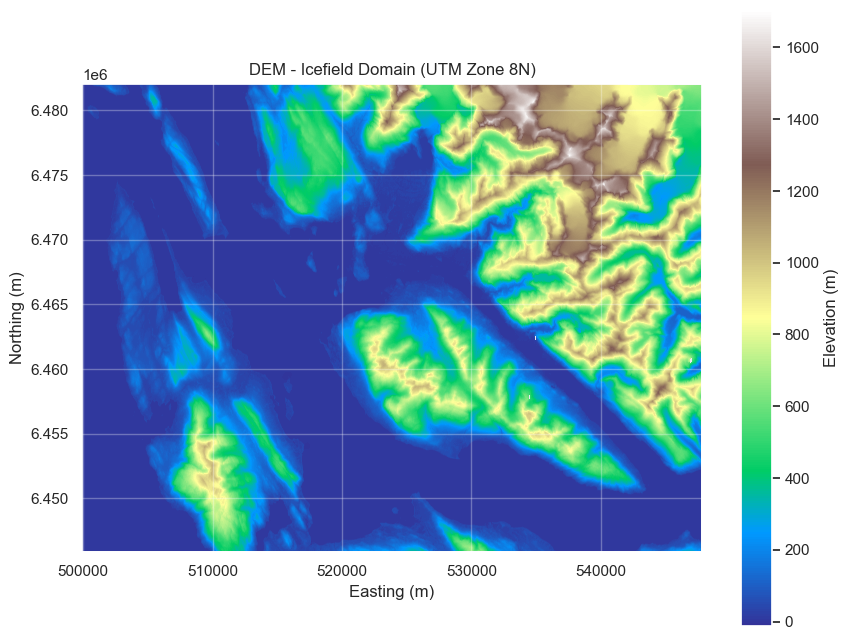

In [ ]:
# Plot the clipped merged DEM with nodata masked
plot_raster_path = os.path.join(out_dir, "dem_2m_UTM_merged_4tiles.tif")

with rasterio.open(plot_raster_path) as src:
    dem_data = src.read(1)
    nodata_val = src.nodata

    if nodata_val is not None:
        dem_plot = np.ma.masked_equal(dem_data, nodata_val)
    else:
        dem_plot = np.ma.masked_invalid(dem_data)

    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    plt.figure(figsize=(10, 8))
    plt.imshow(dem_plot, extent=extent, cmap="terrain", origin="upper")
    plt.colorbar(label="Elevation (m)")
    plt.title("Merged 4-Tile DEM - All Domain (UTM Zone 8N)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# Plot the clipped merged DEM with nodata masked
plot_raster_path = os.path.join(out_dir, "dem_2m_UTM_merged_4tiles_clip_icefield_domain.tif")

with rasterio.open(plot_raster_path) as src:
    dem_data = src.read(1)
    nodata_val = src.nodata

    if nodata_val is not None:
        dem_plot = np.ma.masked_equal(dem_data, nodata_val)
    else:
        dem_plot = np.ma.masked_invalid(dem_data)

    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    plt.figure(figsize=(10, 8))
    plt.imshow(dem_plot, extent=extent, cmap="terrain", origin="upper")
    plt.colorbar(label="Elevation (m)")
    plt.title("Merged 4-Tile DEM - Icefield Domain (UTM Zone 8N)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.grid(True, alpha=0.3)
    plt.show()